In [1]:
import nibabel as nib
import numpy as np
from sklearn.decomposition import PCA
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_subs_from_file_list(fn):
    return [int(x.split("/")[-3]) for x in sorted(list(open(fn).read().split('\n')))[1:]]

def load_4d_niftis(nifti_path, mask_path=None):
    """
    Load 4D niftis and return a 2D numpy array
    """
    niftis = nib.load(nifti_path)
    print("Get niftis data...")
    niftis_data = niftis.get_fdata()
    print("Shape: ", niftis_data.shape)
    niftis_data = np.reshape(niftis_data, (niftis_data.shape[0]*niftis_data.shape[1]*niftis_data.shape[2], niftis_data.shape[3]))
    print("After reshaping: ", niftis_data.shape)

    if mask_path is not None:
        print("Loading mask...")
        mask = nib.load(mask_path).get_fdata()
        mask = np.reshape(mask, (mask.shape[0]*mask.shape[1]*mask.shape[2]))
        niftis_data = niftis_data[mask > 0, :]
        print("After masking:", niftis_data.shape)
    
    # transpose to have shape (n_samples, n_features)
    niftis_data = np.transpose(niftis_data)
    return niftis_data

def check_inverted(file_lists, files_fns, mask_fn, template_fn):
    #load data + subs
    all_subs = []
    for fl in file_lists:
        subs = load_subs_from_file_list(fl)
        all_subs.extend(subs)
    
    all_subs = np.array(all_subs)
    
    all_data_list = []
    
    for i, f in enumerate(files_fns):
        print("Loading file:", f)
        data = load_4d_niftis(f, mask_path = mask_fn)
        print("Data shape:", data.shape)
        all_data_list.append(data)
    all_data = np.vstack(all_data_list)
    all_data = np.transpose(all_data)

    #get indices
    temp_data = load_4d_niftis(template_fn, mask_path = mask_fn)
    sorted_indices = np.argsort(temp_data[0,:])
    top_voxels_wide = sorted_indices[-100:]
    bottom_voxels_wide = sorted_indices[:100]

    #get inverted subs
    top_inversion_subs = []
    bottom_inversion_subs = []
    
    for i in range(all_data.shape[1]):
        top_voxels_data = all_data[top_voxels_wide, i]
        bottom_voxels_data = all_data[bottom_voxels_wide, i]

        top_inverted_percentage = np.sum(top_voxels_data <= 0) / len(top_voxels_data) * 100
        bottom_inverted_percentage = np.sum(bottom_voxels_data >= 0) / len(bottom_voxels_data) * 100

        if top_inverted_percentage > 80:
            top_inversion_subs.append(all_subs[i])
        if bottom_inverted_percentage > 80:
            bottom_inversion_subs.append(all_subs[i])  
    
    top_inversion_subs_wide_set = set(top_inversion_subs)
    bottom_inversion_subs_wide_set = set(bottom_inversion_subs)
    overlap_subs_wide = top_inversion_subs_wide_set.intersection(bottom_inversion_subs_wide_set)
    print("Number of subjects with sign inversion in both top and bottom voxels (wide):", len(overlap_subs_wide))

    #plot distributions
    top_percent = np.sum(all_data[top_voxels_wide,:] <= 0, axis=0) / len(top_voxels_data) * 100
    bottom_percent = np.sum(all_data[bottom_voxels_wide,:] <= 0, axis=0) / len(top_voxels_data) * 100
    #plt.hist(np.mean(all_data[top_voxels_wide,:], axis=0), range=(-0.03, 0.03), bins=100)
    plt.hist(top_percent, range=(0, 100), bins=100)
    plt.title("Distribution percentage sign-flip in top voxels")
    plt.show()
    plt.hist(top_percent, range=(0, 100), bins=100)
    #plt.hist(np.mean(all_data[bottom_voxels_wide,:], axis=0), range=(-0.03, 0.03), bins=100)
    plt.title("Distribution percentage sign-flip in bottom voxels")
    plt.show()
    return list(overlap_subs_wide)

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [2]:
files_fns = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_template.nii.gz"] #,
            #"/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_non_template.nii.gz"]

base_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/"
roi="lstg"

file_lists = [os.path.join(base_path, roi, "file_list_template.txt")]
                #os.path.join(base_path, roi, "file_list_non_template.txt")]

mask_fn="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lstg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template/lstg/roi_lstg.cmaps.nii.gz"

Loading file: /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_template.nii.gz
Get niftis data...
Shape:  (91, 109, 91, 11244)
After reshaping:  (902629, 11244)
Loading mask...
After masking: (1171, 11244)
Data shape: (11244, 1171)
Get niftis data...
Shape:  (91, 109, 91, 3)
After reshaping:  (902629, 3)
Loading mask...
After masking: (1171, 3)
Number of subjects with sign inversion in both top and bottom voxels (wide): 1


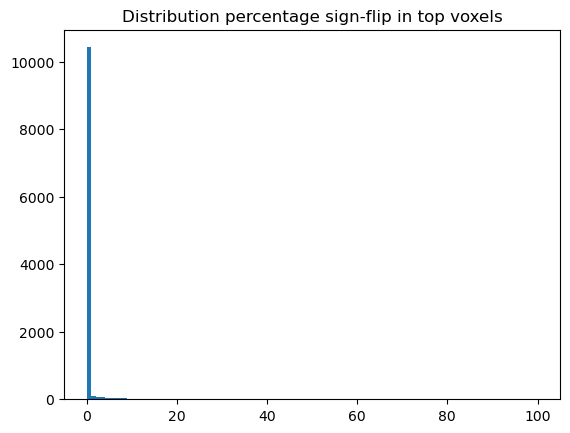

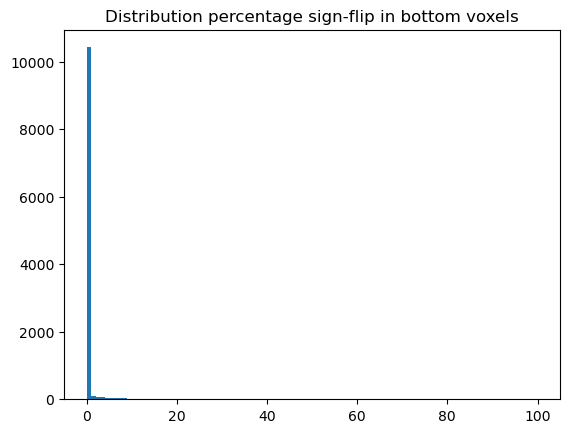

In [3]:
lstg_inverted = check_inverted(file_lists,
               files_fns,
               mask_fn,
               template_fn)

In [ ]:
files_fns = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_non_template.nii.gz"]
base_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/"
roi="lstg"
file_lists = [ os.path.join(base_path, roi, "file_list_non_template.txt")]
mask_fn="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lstg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template/lstg/roi_lstg.cmaps.nii.gz"

lstg_inverted = check_inverted(file_lists,
               files_fns,
               mask_fn,
               template_fn)

Loading file: /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lstg/all_data_lstg_g1_cmap_non_template.nii.gz
Get niftis data...


Loading file: /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/all_data_lifg_g1_cmap_template.nii.gz
Get niftis data...
Shape:  (91, 109, 91, 11372)
After reshaping:  (902629, 11372)
Loading mask...
After masking: (1276, 11372)
Data shape: (11372, 1276)
Get niftis data...
Shape:  (91, 109, 91, 3)
After reshaping:  (902629, 3)
Loading mask...
After masking: (1276, 3)
Number of subjects with sign inversion in both top and bottom voxels (wide): 0


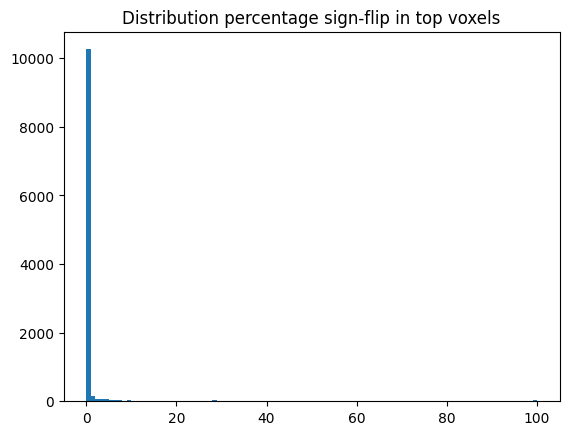

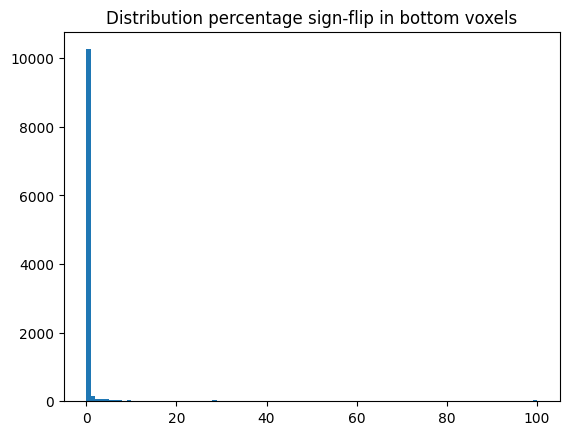

In [4]:
files_fns = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/all_data_lifg_g1_cmap_template.nii.gz"]
            #"/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g0/cmap/lifg/all_data_lifg_g1_cmap_non_template.nii.gz"]

base_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/"
roi="lifg"

file_lists = [os.path.join(base_path, roi, "file_list_template.txt")]
              #  os.path.join(base_path, roi, "file_list_non_template.txt")]

mask_fn="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lifg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template/lifg/roi_lifg.cmaps.nii.gz"

lifg_inverted = check_inverted(file_lists,
               files_fns,
               mask_fn,
               template_fn)

In [ ]:
files_fns = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/lifg/all_data_lifg_g1_cmap_non_template.nii.gz"]

base_path="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/melodic/g1/cmap/"
roi="lifg"

file_lists = [os.path.join(base_path, roi, "file_list_non_template.txt")]

mask_fn="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lifg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template/lifg/roi_lifg.cmaps.nii.gz"

lifg_inverted = check_inverted(file_lists,
               files_fns,
               mask_fn,
               template_fn)

In [ ]:
print("LSTG inverted:")
print(len(lstg_inverted))
print("LIFG inverted:")
print(len(lifg_inverted))

In [ ]:
def to_list(in_list, fn):
    with open(fn, "w") as file:
        for row in in_list:
            file.write(str(row)+'\n')

to_list(in_list = lstg_inverted,
        fn = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/lstg_g1_inverted_new.txt")
to_list(in_list = lifg_inverted,
        fn = "/data/workspaces/lag/workspaces/lg-ukbiobank/projects/CONGRADS_rest/lifg_g1_inverted_new.txt")

In [ ]:
#make 4d file
#ls /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/out/*/lstg/roi_lstg_aligned_0_cmap_HCP.nii.gz > /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/file_list.txt
#ls /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/out/*/lifg/roi_lifg_aligned_0_cmap_HCP.nii.gz > /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/file_list.txt

#fslmerge -t /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/all_data_lstg_HCP_cmap.nii.gz $(cat /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/file_list.txt)
#fslmerge -t /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/all_data_lifg_HCP_cmap.nii.gz $(cat /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/file_list.txt)


Loading file: /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/all_data_lstg_HCP_cmap.nii.gz
Get niftis data...
Shape:  (91, 109, 91, 667)
After reshaping:  (902629, 667)
Loading mask...
After masking: (1171, 667)
Data shape: (667, 1171)
Get niftis data...
Shape:  (91, 109, 91, 3)
After reshaping:  (902629, 3)
Loading mask...
After masking: (1171, 3)
Number of subjects with sign inversion in both top and bottom voxels (wide): 622


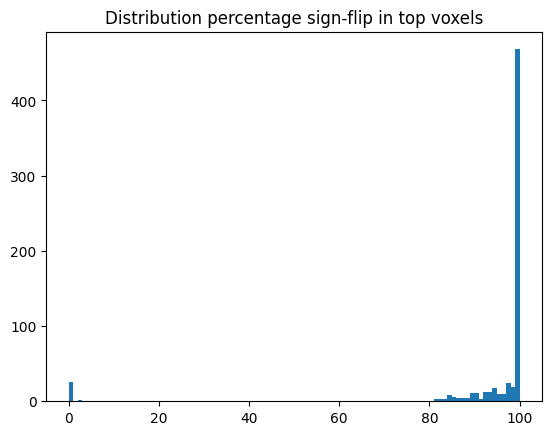

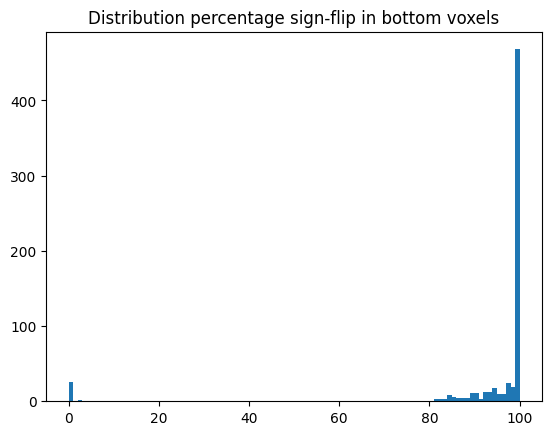

In [2]:
file_list_lstg = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/file_list.txt"]
file_lstg_4d = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lstg/all_data_lstg_HCP_cmap.nii.gz"]
mask_lstg = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lstg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template_HCP/lstg/roi_lstg.cmaps.nii.gz"

lstg_inverted_HCP = check_inverted(file_list_lstg,
               file_lstg_4d,
               mask_lstg,
               template_fn)

Loading file: /data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/all_data_lifg_HCP_cmap.nii.gz
Get niftis data...
Shape:  (91, 109, 91, 6366)
After reshaping:  (902629, 6366)
Loading mask...
After masking: (1171, 6366)
Data shape: (6366, 1171)
Get niftis data...
Shape:  (91, 109, 91, 3)
After reshaping:  (902629, 3)
Loading mask...
After masking: (1171, 3)
Number of subjects with sign inversion in both top and bottom voxels (wide): 6366


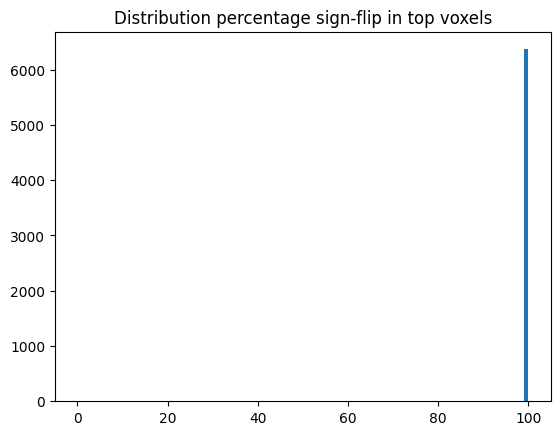

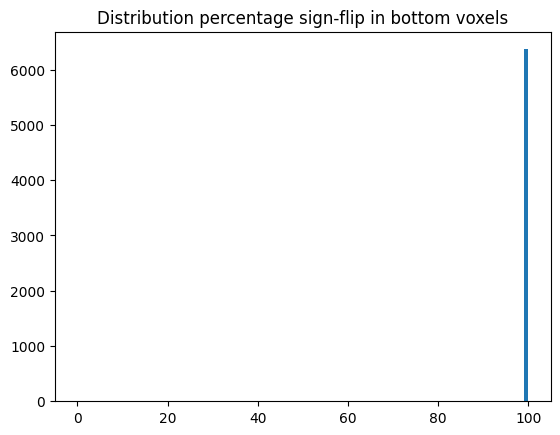

In [4]:
file_lifg_4d = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/all_data_lifg_HCP_cmap.nii.gz"]
file_list_lifg = ["/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/flipped_check/lifg/file_list.txt"]
mask_fn="/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/mask/roi_lifg.nii.gz"
template_fn = "/data/clusterfs/lag/projects/lg-ukbiobank/working_data/imaging_data/CONGRADS_rest/template_HCP/lifg/roi_lifg.cmaps.nii.gz"

lifg_inverted_HCP = check_inverted(file_list_lifg,
               file_lifg_4d,
               mask_lstg,
               template_fn)